In [39]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np

In [14]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [15]:
cases = ["M1_A1","S1"]
projects = ["nl_exb_scan"]

In [ ]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        json_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.nc"))
        gene_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
        gene_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        case_dict[case] = gene_pyoscan
        project_dict[project] = case_dict

/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0045'. 
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0046) is inconsistent with value from physical reference values (0.09617910133883377 beta_ref_ee_B0_pyroscan_base0046)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0046'. 
  warnings.warn(


In [ ]:
tglf_versions = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules = ["sat1","sat2","sat3"]
tglf_grid_models = [1,4]
width_neg = [0,1]
tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            sat_rules = {}
            for sat_rule in tglf_sat_rules:
                grid_models = {}
                for grid_model in tglf_grid_models:
                    json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/{version}/{sat_rule}_kygrid{grid_model}/pyroscan.json"))
                    net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/{version}/{sat_rule}_kygrid{grid_model}/pyroscan.nc"))
                    try:
                        tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                        tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                        grid_models[grid_model] = tglf_pyoscan
                    except Exception as e:
                        print(f"Error loading pyroscan for {project}/{case}/{version}/{sat_rule}_kygrid{grid_model}: {e}")
                sat_rules[sat_rule] = grid_models
            version_dict[version] = sat_rules
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Error loading pyroscan for nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid1/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid4/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid1/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid4/pyroscan.json'
Error loading pyroscan for nl_exb_scan/S1/tglf_default/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyr

In [ ]:
# tglf_versions = ["_","_V1_","_V2_"]
# tglf_sat_rules = ["S1","S2","S3"]
# tglf_grid_models = ["K1","K4"]
# tglf_project_dict ={}
# for project in projects:
#     case_dict = {}
#     for case in cases:
#         version_dict = {}
#         for version in tglf_versions:
#             sat_rules = {}
#             for sat_rule in tglf_sat_rules:
#                 grid_models = {}
#                 for grid_model in tglf_grid_models:
#                     json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/scan_exb_with_PVG/{case}/parameter_scan_tglf{version}{sat_rule}_{grid_model}/pyroscan.json"))
#                     net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/scan_exb_with_PVG/{case}/parameter_scan_tglf{version}{sat_rule}_{grid_model}/pyroscan.cdf"))
#                     try:
#                         tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
#                         tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
#                         grid_models[grid_model] = tglf_pyoscan
#                     except Exception as e:
#                         print(f"Error loading pyroscan for {project}/{case}/{version}/{sat_rule}_kygrid{grid_model}: {e}")
#                 sat_rules[sat_rule] = grid_models
#             version_dict[version] = sat_rules
#         case_dict[case] = version_dict
#     tglf_project_dict[project] = case_dict

Error loading pyroscan for nl_exb_scan/S1/_/S1_kygridK1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_exb_with_PVG/S1/parameter_scan_tglf_S1_K1/pyroscan.cdf'
Error loading pyroscan for nl_exb_scan/S1/_/S1_kygridK4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_exb_with_PVG/S1/parameter_scan_tglf_S1_K4/pyroscan.cdf'
Error loading pyroscan for nl_exb_scan/S1/_/S2_kygridK1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_exb_with_PVG/S1/parameter_scan_tglf_S2_K1/pyroscan.cdf'
Error loading pyroscan for nl_exb_scan/S1/_/S2_kygridK4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_exb_with_PVG/S1/parameter_scan_tglf_S2_K4/pyroscan.cdf'
Error loading pyroscan for nl_exb_scan/S1/_/S3_kygridK1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_exb_with_PVG/S1/parameter_scan_tglf_S3_K1/pyroscan.cdf'


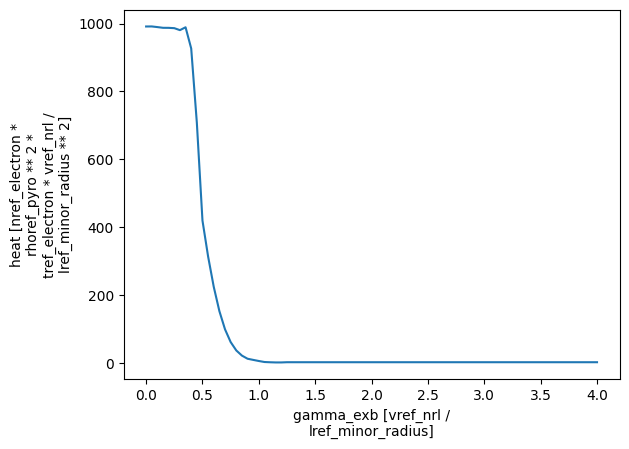

In [28]:
tglf_project_dict["nl_exb_scan"]["M1_A1"]["tglf_v1"]["sat1"][1].gk_output["heat"].sum(dim="species").sum(dim="field").plot()

KeyError: 1

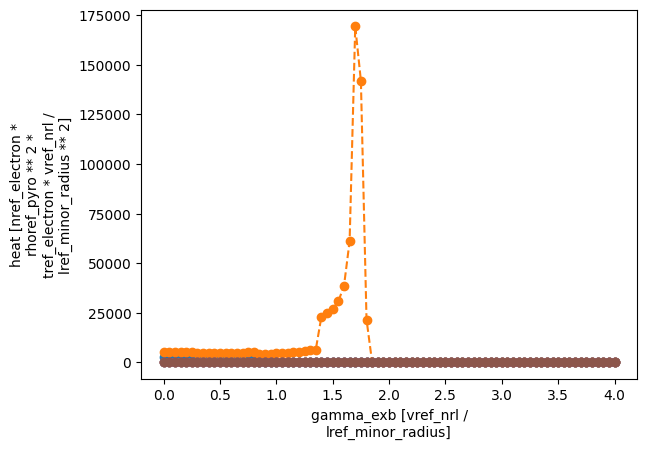

In [65]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_exb = 3.49


for tglf in tglf_versions:
    for sat_rule in tglf_sat_rules:
        for grid_model in tglf_grid_models:
            (tglf_project_dict[project][case][tglf][sat_rule][grid_model]
                .gk_output["heat"].sum(dim="species").sum(dim="field")
                .plot(label=tglf, marker="o", linestyle="--"))



project_dict[project][case].gk_output["heat"].sum(dim="species").sum(dim="field").plot(label="GENE", color="black", marker="o")



#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.xlabel(r"\gamma_{ExB}")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
plt.yscale("log")
plt.xscale("log")
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Document

Plotting tglf_default sat2 grid model 4
Plotting tglf_default_negwm sat2 grid model 4
Plotting tglf_v1 sat2 grid model 4
Plotting tglf_v1_negwm sat2 grid model 4
Plotting tglf_v2 sat2 grid model 4


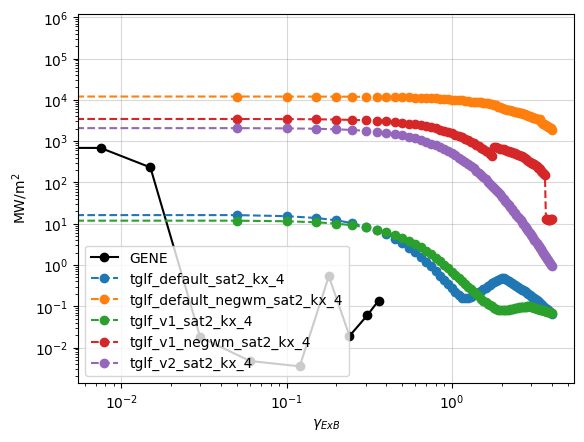

In [77]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_exb = 3.49

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


GENE_context = project_dict[project][case].base_pyro.norms.context

GENE_Heat = project_dict[project][case].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2",GENE_context)
GENE_exb = project_dict[project][case].gk_output["heat"]["gamma_exb"]
plt.plot(GENE_exb,np.abs(GENE_Heat), label="GENE", color="black", marker="o")

for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            print(f"Plotting {tglf} {sat_rule} grid model {grid_model}")
            try:
                tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2",GENE_context)
                tglf_exb = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"]["gamma_exb"]
                plt.plot(tglf_exb, np.abs(tglf_heat), label=f"{tglf}_{sat_rule}_kx_{grid_model}", marker="o", linestyle="--")
            except Exception as e:
                print(f"Error plotting {tglf} {sat_rule} grid model {grid_model}: {e}")




#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.ylabel(r"MW/m$^2$")
plt.xlabel(r"$\gamma_{ExB}$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
plt.yscale("log")
plt.xscale("log")
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



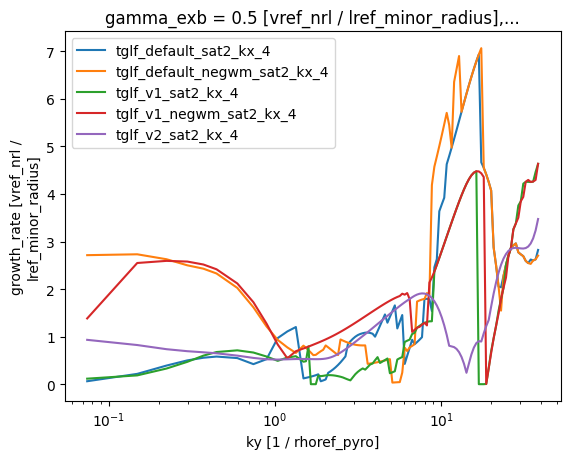

In [75]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_exb = 3.49

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["growth_rate"].isel(gamma_exb=10).isel(mode=0).plot(label=f"{tglf}_{sat_rule}_kx_{grid_model}")

plt.legend()
plt.xscale("log")